In [1]:
from envsv3 import SingleLaneEnv, BasisActionWrapper, SafetyWrapper

import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import os

%matplotlib inline

In [2]:
def setup(exp_n=1, T=40.0, dt=0.05, macro_dt=1.0, K=20, al=8,
          h0=2.0, alphaV_safe=1.0, beta=1.0,
          use_best=True, last_check=None):
    run_dir = os.path.expanduser(f"~/tb_logs/runs/ppo_singlelane_stable_saf_{exp_n}")

    def make_env():
        env = SingleLaneEnv(T=T, dt=dt, macro_dt=macro_dt, al=al)
        env = BasisActionWrapper(env, K=K)
        env = SafetyWrapper(env, h0=h0, alphaV=alphaV_safe, beta=beta)
        return env

    vec_env = DummyVecEnv([make_env])

    if last_check is not None:
        vn_path = os.path.join(run_dir, f"ppo_ckpt_vecnormalize_{last_check}_steps.pkl")
    else:
        vn_path = os.path.join(run_dir, "vecnormalize.pkl")

    vec_env = VecNormalize.load(vn_path, vec_env)
    vec_env.training = False
    vec_env.norm_reward = False

    if use_best:
        model_path = os.path.join(run_dir, "best_safe", "best_model")
    else:
        model_path = os.path.join(run_dir, "ppo_safe_final")

    model = PPO.load(model_path, env=vec_env)

    # L'env interne réel (celui utilisé pendant le rollout)
    base_env = vec_env.venv.envs[0]
    return base_env, vec_env, model

In [3]:
def rollout(base_env, vec_env, model, deterministic=True):
    obs = vec_env.reset()

    done = False
    total_reward = 0.0

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, done_arr, infos = vec_env.step(action)

        total_reward += float(reward[0])
        done = bool(done_arr[0])

        if not done:
            vec_env.venv.envs[0].render()

    print(f"Total reward: {total_reward:.4f}")

# Safe PPO v3 — exp 1

In [4]:
base_env, vec_env, model = setup(exp_n=1, T=40.0, dt=0.05, macro_dt=1.0,
                                  K=20, al=8, h0=2.0, alphaV_safe=1.0, beta=1.0,
                                  use_best=True, last_check=250000)

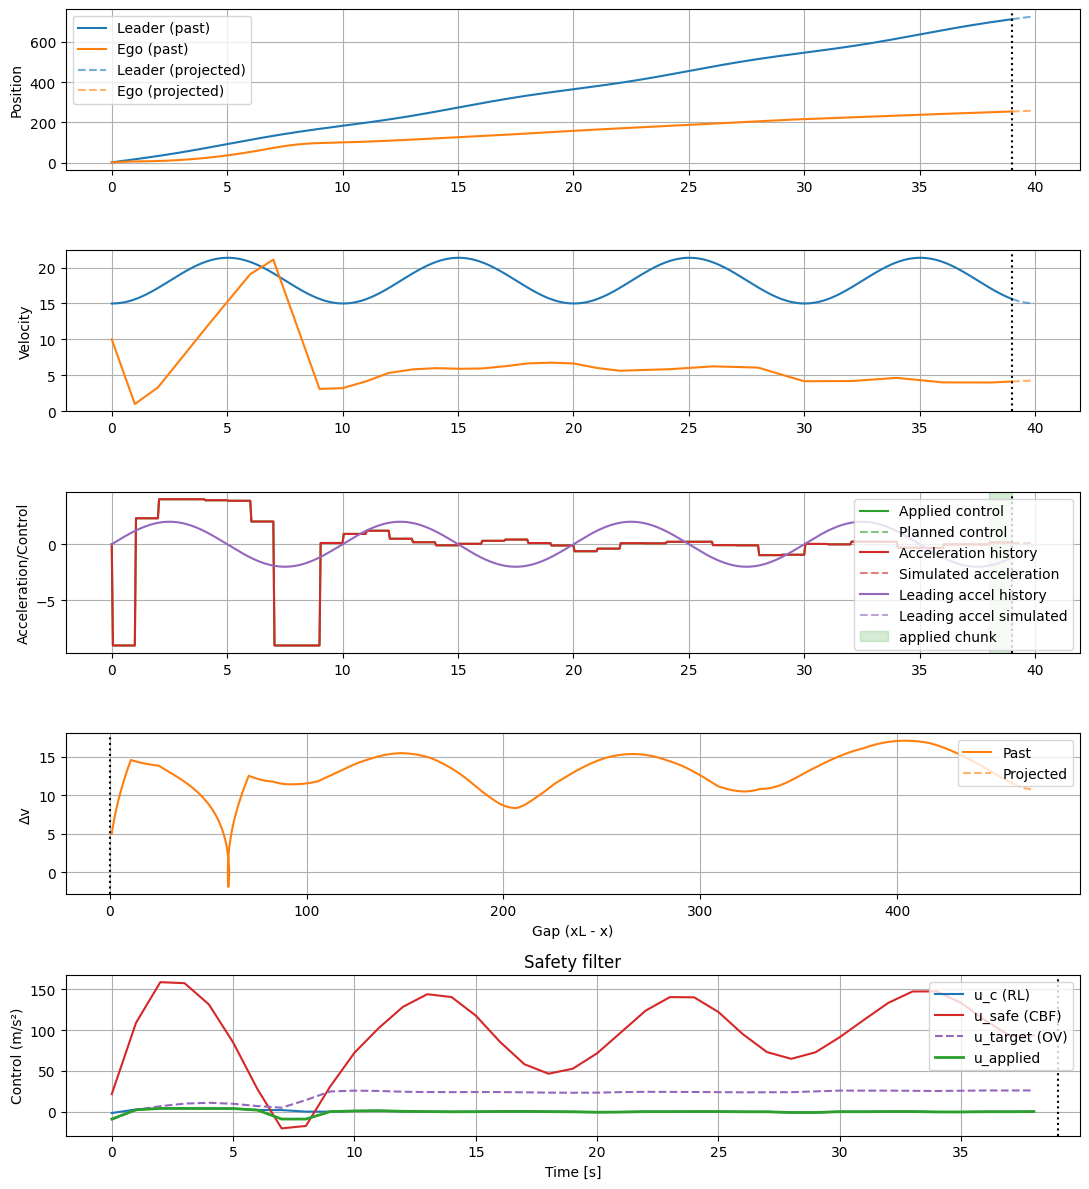

Total reward: -143.5337


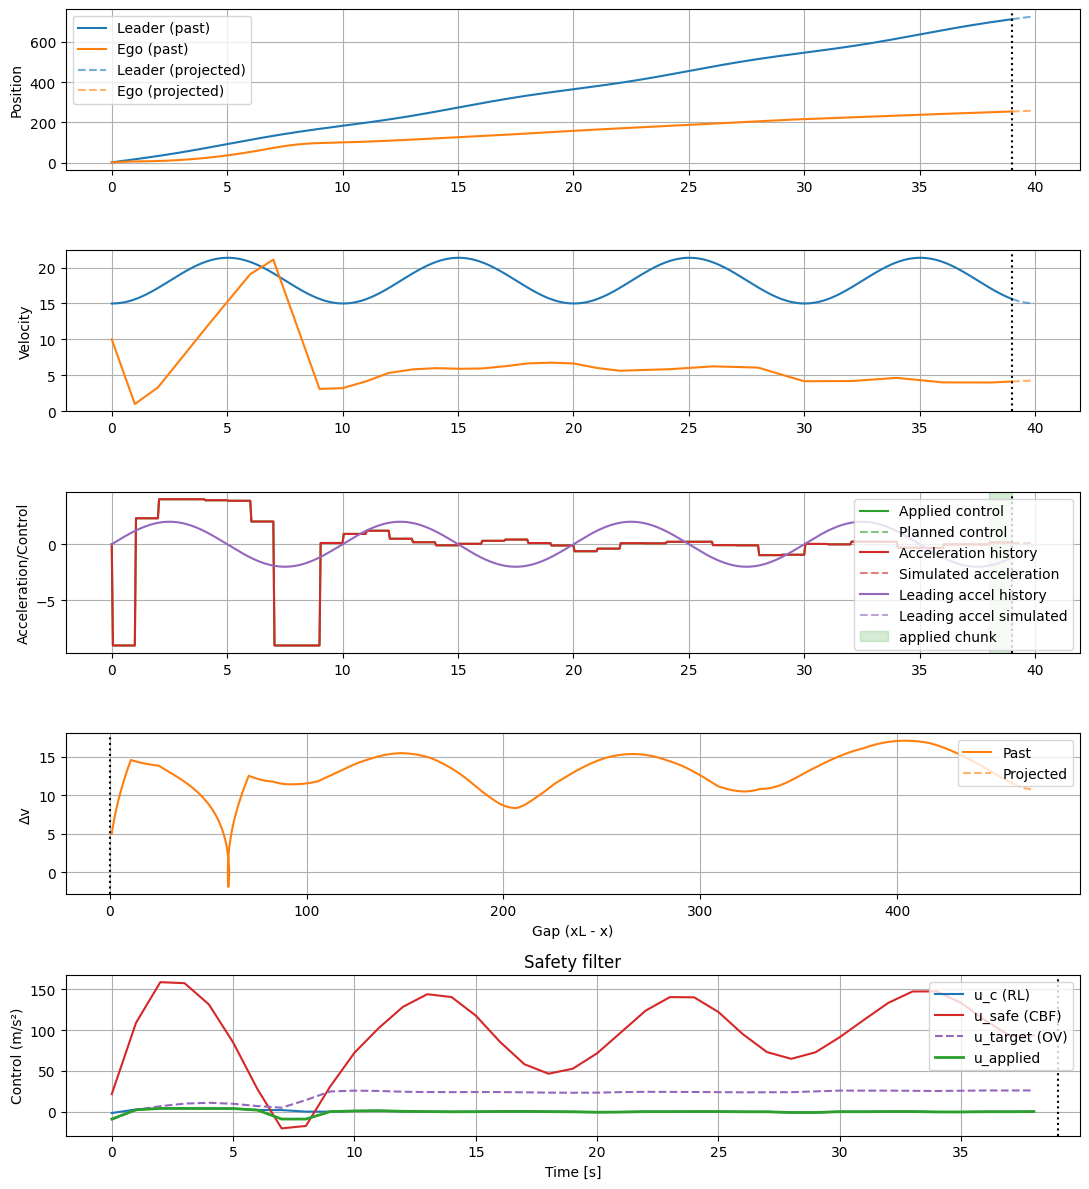

In [5]:
rollout(base_env, vec_env, model, deterministic=True)

# Depuis un checkpoint intermédiaire

In [ ]:
# Remplacer last_check par le nombre de steps du checkpoint voulu (ex: 200000, 350000...)
base_env2, vec_env2, model2 = setup(exp_n=1, use_best=False, last_check=200000)
rollout(base_env2, vec_env2, model2, deterministic=True)

# Rollout stochastique (deterministic=False)

In [ ]:
base_env3, vec_env3, model3 = setup(exp_n=1, use_best=True)
rollout(base_env3, vec_env3, model3, deterministic=False)